# 05_统计检验方法-皮尔逊相关系数检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们聊聊统计检验方法：皮尔逊相关系数检验。

首先，皮尔逊相关系数检验（Pearson Correlation Test）是一种用来衡量两个变量之间线性关系强度和方向的统计方法。

简单来说，它能告诉你两个事物之间是否有关系，并且这种关系是正相关、负相关，还是没有明显的关系。

### 1. 皮尔逊相关系数（r）是什么？

皮尔逊相关系数（r）是一个数字，它的值范围在 -1 到 +1 之间：

- **r = +1**：表示两个变量之间有完美的正相关关系，意味着当一个变量增加时，另一个变量也总是增加，且关系非常稳定。
- **r = -1**：表示两个变量之间有完美的负相关关系，意味着当一个变量增加时，另一个变量总是减少，且这种关系也非常稳定。
- **r = 0**：表示两个变量之间没有线性关系，换句话说，它们之间没有明显的关联。
- **r = 介于 -1 和 +1 之间**：表示两个变量之间有某种程度的相关关系，值越接近 +1 或 -1，表示关系越强，越接近 0，表示关系越弱。

### 2. 怎么理解皮尔逊相关系数的检验？

皮尔逊相关系数检验的目的是通过统计方法来判断你得到的样本数据中的相关系数，是否有足够的证据支持“两个变量之间确实有相关性”这个结论。

#### 假设检验步骤：

- **零假设（H₀）**：假设两个变量之间没有任何线性关系，皮尔逊相关系数为 0。
- **备择假设（H₁）**：假设两个变量之间有线性关系，皮尔逊相关系数不为 0。

然后，我们根据数据计算出皮尔逊相关系数，并通过统计方法判断这个系数是否显著不同于 0。如果显著不同，我们就可以拒绝零假设，认为两个变量之间可能存在关系。

举个例子，假设你想知道学生的学习时间和考试成绩之间是否有关系。你收集了一些数据，记录了不同学生的学习时间和他们的考试成绩。接下来，使用皮尔逊相关系数计算出一个值。

- 如果计算出来的 r 值接近 +1，说明学习时间和考试成绩之间有很强的正相关关系，学生学习时间越长，考试成绩越好。
- 如果 r 值接近 -1，说明学习时间和考试成绩之间有很强的负相关关系，学习时间越长，考试成绩反而越差。
- 如果 r 值接近 0，说明学习时间和考试成绩之间没有明显的关系。

需要注意的事项：

- 皮尔逊相关系数只能检测**线性关系**，如果两个变量之间有非线性的关系，皮尔逊相关系数可能无法准确反映它们之间的关系。
- 样本数量和数据的分布会影响检验的结果。如果样本量太小，可能得不到准确的结论。

总之，皮尔逊相关系数检验是一种很有用的工具，帮助我们判断两个变量之间是否存在线性关系，了解它们之间的联系有多强。

## 原理详解

**皮尔逊相关系数检验** 用于衡量两个变量之间的线性关系。

其核心目标是通过计算皮尔逊相关系数 $r$，来判断两个变量之间是否存在显著的线性关系。

以下是皮尔逊相关系数检验的详细数学原理、公式推理和算法流程。

### 1. 皮尔逊相关系数（$r$）的定义与计算公式

皮尔逊相关系数（Pearson Correlation Coefficient）是衡量两个变量之间线性关系强度的统计量。

计算公式：


$$
r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}
$$


其中：

- $X_i$和 $Y_i$是第 $i$个样本的观测值。
- $\bar{X}$和 $\bar{Y}$是变量 $X$和 $Y$的样本均值。
- $n$是样本数量。

### 2. 公式推理与数学原理

**均值的作用**：

皮尔逊相关系数考虑了两个变量 $X$ 和 $Y$ 偏离其均值的程度。公式中，$(X_i - \bar{X})$和 $(Y_i - \bar{Y})$分别表示每个观测值与其均值的偏差。

**协方差**：

公式中的分子部分， $\sum (X_i - \bar{X})(Y_i - \bar{Y})$，实际上是两个变量的**协方差**的计算。这部分衡量了两个变量偏差的相互关系。如果协方差为正，表示两个变量之间存在正相关；如果为负，表示负相关；如果为零，表示没有线性关系。

协方差的计算公式为：


$$
\text{cov}(X, Y) = \frac{1}{n-1} \sum (X_i - \bar{X})(Y_i - \bar{Y})
$$


在皮尔逊相关系数公式中，协方差的计算式被标准化（即除以标准差），以便消除不同变量的量纲差异。

**标准化：标准差的作用**

公式中的分母部分，$\sqrt{\sum (X_i - \bar{X})^2}$和 $\sqrt{\sum (Y_i - \bar{Y})^2}$，分别是 $X$ 和 $Y$ 的**标准差**。

标准差度量了变量的分散程度，即每个观测值与均值的平均偏离程度。

标准差的公式：


$$
\sigma_X = \sqrt{\frac{1}{n-1} \sum (X_i - \bar{X})^2}
$$


标准差通过标准化协方差的计算，使得皮尔逊相关系数的值不受变量的单位影响。最终的相关系数 $r$ 值介于 -1 和 1 之间，反映了两个变量之间的线性关系强度和方向。

### 3. 皮尔逊相关系数的性质

- **范围**：$r$ 的值总是介于 -1 和 +1 之间。$r = 1$ 表示完全正相关，$r = -1$ 表示完全负相关，$r = 0$ 表示无线性关系。
- **线性关系**：皮尔逊相关系数只衡量线性关系。如果两个变量之间存在非线性关系，皮尔逊相关系数可能为 0，但实际上它们之间可能存在某种非线性关系。
- **对称性**：皮尔逊相关系数是对称的，即 $r(X, Y) = r(Y, X)$，说明 $X$ 和 $Y$ 的关系是一样的。
- **敏感性**：皮尔逊相关系数对异常值非常敏感。极端的异常值可能显著影响相关系数的计算结果。

### 4. 假设检验的过程

皮尔逊相关系数检验的基本思想是基于假设检验的方法来判断两个变量之间是否存在线性关系。

常用的步骤：

#### 提出假设

- **零假设（**$H_0$**)**：假设两个变量之间没有线性关系，即 $r = 0$。
- **备择假设（**$H_1$**)**：假设两个变量之间存在线性关系，即 $r \neq 0$（双尾检验）或 $r > 0$（单尾检验）或 $r < 0$（单尾检验）。

#### 计算样本的皮尔逊相关系数

根据样本数据计算皮尔逊相关系数 $r$。

#### 计算 t 统计量

通过皮尔逊相关系数 $r$ 来计算 t 统计量，用于检验是否拒绝零假设。

t 统计量的计算公式为：


$$
t = \frac{r \sqrt{n - 2}}{\sqrt{1 - r^2}}
$$


其中：

- $n$ 是样本大小。
- $r$ 是样本的皮尔逊相关系数。

#### 确定自由度

自由度 $df$ 的计算公式为：$df = n - 2$

#### 查找临界值并做出决策

根据给定的显著性水平（例如 0.05），查找对应自由度下的临界 t 值。然后，比较计算得到的 t 值与临界 t 值：

- 如果计算出的 t 值的绝对值大于临界 t 值，拒绝零假设，认为两个变量之间存在线性关系。
- 如果计算出的 t 值的绝对值小于临界 t 值，不能拒绝零假设，认为两个变量之间没有显著的线性关系。

### 5. 总结几点

- **皮尔逊相关系数** $r$ 用于衡量两个变量之间的线性关系，计算公式是基于协方差和标准差的标准化。
- **假设检验** 的过程包括计算 t 统计量，并根据显著性水平判断是否拒绝零假设，进而得出结论。
- 皮尔逊相关系数检验是一种非常有效的工具，广泛应用于各种数据分析中，帮助我们理解变量之间的关系。

## 完整案例

假设我们有一个关于**学生学习时间与考试成绩**的数据集，目的是研究**学习时间与考试成绩**之间的线性关系。

我们会通过计算皮尔逊相关系数来检验它们之间的相关性，并通过可视化进一步分析结果。

### 数据生成

我们生成一个模拟的数据集，其中包含 100 个学生的学习时间（单位：小时）和考试成绩（单位：分数）。

我们期望两者之间存在线性关系，但可能会受到噪音（random noise）的影响。

### 1. 数据生成与导入

首先，我们生成两个变量（学习时间和考试成绩）的模拟数据。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 设置随机种子以确保结果可复现
np.random.seed(42)

# 生成模拟数据：学习时间（X）和考试成绩（Y）
n = 1000  # 样本数
study_time = np.random.normal(5, 1.5, n)  # 学习时间，均值5小时，标准差1.5小时
exam_scores = 50 + 10 * study_time + np.random.normal(0, 10, n)  # 考试成绩，受学习时间影响，并加上噪音

# 创建 DataFrame
data = pd.DataFrame({
    'StudyTime': study_time,
    'ExamScores': exam_scores
})

# 查看前几行数据
data.head()

,StudyTime,ExamScores
0,5.745071,121.444267
1,4.792604,107.172372
2,5.971533,110.311632
3,7.284545,116.376080
4,4.648770,103.469933


### 2. 数据的初步分析与描述统计

我们首先对数据进行简单的描述性统计分析，了解数据的分布情况。

In [3]:
# 描述性统计分析
data.describe()

,StudyTime,ExamScores
count,1000.000000,1000.000000
mean,5.028998,100.998343
std,1.468824,17.418325
min,0.138099,52.739524
25%,4.028615,90.021093
50%,5.037951,100.630546
75%,5.971916,111.900419
max,10.779097,175.286740


输出的内容包括数据的均值、标准差、最小值、最大值等信息，帮助我们初步了解数据的基本情况。

### 3. 可视化：学习时间与考试成绩的散点图

为了直观地了解学习时间与考试成绩之间的关系，我们绘制一个散点图。

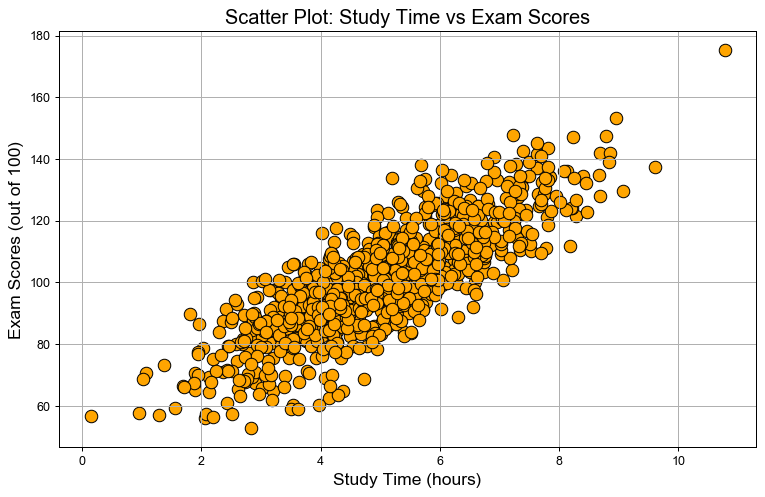

In [4]:
# 绘制散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StudyTime', y='ExamScores', data=data, color='orange', s=100, edgecolor='black')
plt.title('Scatter Plot: Study Time vs Exam Scores', fontsize=16)
plt.xlabel('Study Time (hours)', fontsize=14)
plt.ylabel('Exam Scores (out of 100)', fontsize=14)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

### 4. 计算皮尔逊相关系数

接下来，我们使用`scipy.stats`库中的`pearsonr`函数来计算皮尔逊相关系数。

In [5]:
# 计算皮尔逊相关系数
corr_coefficient, p_value = pearsonr(data['StudyTime'], data['ExamScores'])

print(f'Pearson correlation coefficient: {corr_coefficient}')
print(f'p-value: {p_value}')

Pearson correlation coefficient: 0.8201287356691748
p-value: 3.1993057132877526e-244


皮尔逊相关系数 $r$ 的值会告诉我们学习时间与考试成绩之间的线性关系强度和方向：

$r$ 值接近 +1 表示强正相关。

$r$ 值接近 -1 表示强负相关。

$r$ 值接近 0 表示无线性关系。

`p-value` 用于检验零假设（即 $r = 0$，即没有线性关系）的显著性。如果 `p-value` 小于设定的显著性水平（例如 0.05），我们可以拒绝零假设，认为学习时间与考试成绩之间存在线性关系。

### 5. 假设检验分析

在计算皮尔逊相关系数后，我们还需要进行假设检验，判断该相关性是否显著。

In [6]:
# 判断相关性是否显著
alpha = 0.05  # 显著性水平

if p_value < alpha:
    print("There is a significant linear relationship between study time and exam scores.")
else:
    print("There is no significant linear relationship between study time and exam scores.")

There is a significant linear relationship between study time and exam scores.


如果 `p-value` 小于 0.05，说明我们可以拒绝零假设，认为学习时间与考试成绩之间存在显著的线性关系。

### 6. 可视化：回归线的添加

为了更直观地观察线性关系，我们可以绘制一条回归线（拟合线）到散点图中。

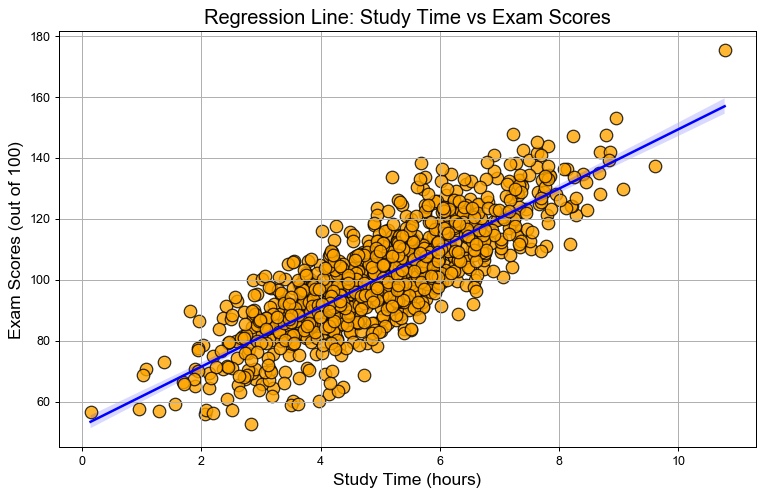

In [7]:
# 绘制回归线
plt.figure(figsize=(10, 6))
sns.regplot(x='StudyTime', y='ExamScores', data=data, scatter_kws={'color': 'orange', 's': 100, 'edgecolor': 'black'}, line_kws={'color': 'blue', 'lw': 2})
plt.title('Regression Line: Study Time vs Exam Scores', fontsize=16)
plt.xlabel('Study Time (hours)', fontsize=14)
plt.ylabel('Exam Scores (out of 100)', fontsize=14)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_014.png)

在回归图中，橙色的点代表数据点，而蓝色的线是通过最小二乘法拟合出的回归线，帮助我们观察学习时间与考试成绩之间的线性关系。

### 7. 数据的优化与回归分析

对于实际应用中的数据，可能会受到噪声的影响，因此我们可以尝试使用一些优化方法来提高分析的准确性。例如，数据的平滑、去除异常值等。

#### 异常值检测与去除

首先，使用箱型图检查数据是否存在异常值。

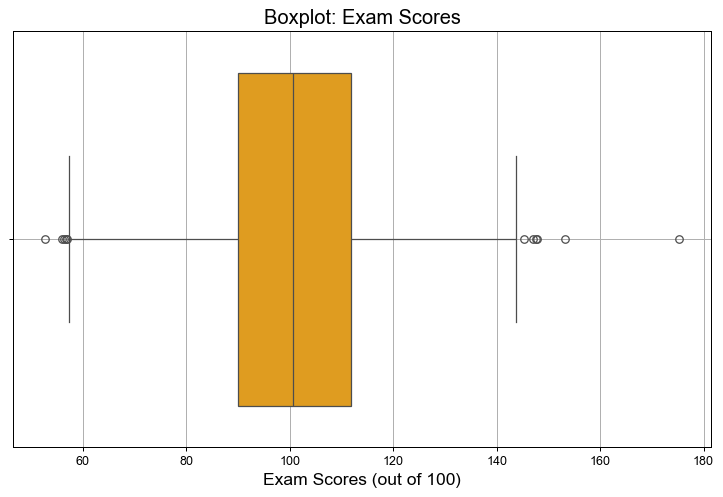

In [8]:
# 绘制箱型图来检测异常值
plt.figure(figsize=(10, 6))
sns.boxplot(x='ExamScores', data=data, color='orange')
plt.title('Boxplot: Exam Scores', fontsize=16)
plt.xlabel('Exam Scores (out of 100)', fontsize=14)
plt.grid(True)
plt.show()

如果数据中存在异常值，我们可以根据箱型图的规则（例如超出上限1.5倍四分位距的值）来去除它们。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

#### 平滑数据：去噪声

通过简单的平滑技术（如移动平均）减少数据中的噪声。

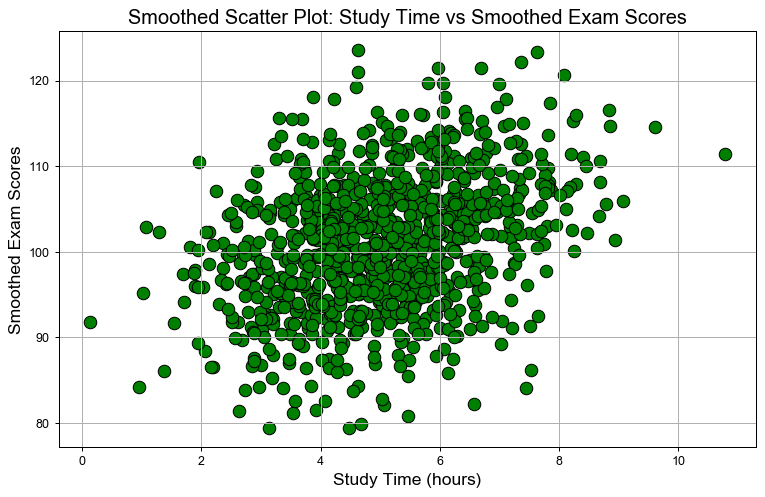

In [9]:
# 使用滑动窗口方法进行平滑
data['SmoothScores'] = data['ExamScores'].rolling(window=5).mean()

# 绘制平滑后的数据
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StudyTime', y='SmoothScores', data=data, color='green', s=100, edgecolor='black')
plt.title('Smoothed Scatter Plot: Study Time vs Smoothed Exam Scores', fontsize=16)
plt.xlabel('Study Time (hours)', fontsize=14)
plt.ylabel('Smoothed Exam Scores', fontsize=14)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_016.png)

### 8. 优化算法：考虑不同的数据分布

对于实际应用中的数据，可能存在不同类型的分布，因此我们可以根据数据分布来选择不同的算法或模型。

#### 标准化数据：

对数据进行标准化处理，使得数据的均值为0，标准差为1。

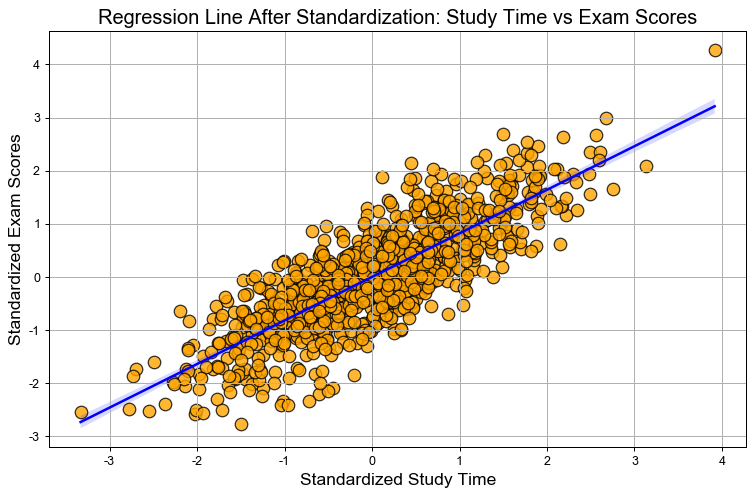

In [10]:
from sklearn.preprocessing import StandardScaler

# 标准化学习时间和考试成绩
scaler = StandardScaler()
data[['StudyTime', 'ExamScores']] = scaler.fit_transform(data[['StudyTime', 'ExamScores']])

# 重新绘制回归图
plt.figure(figsize=(10, 6))
sns.regplot(x='StudyTime', y='ExamScores', data=data, scatter_kws={'color': 'orange', 's': 100, 'edgecolor': 'black'}, line_kws={'color': 'blue', 'lw': 2})
plt.title('Regression Line After Standardization: Study Time vs Exam Scores', fontsize=16)
plt.xlabel('Standardized Study Time', fontsize=14)
plt.ylabel('Standardized Exam Scores', fontsize=14)
plt.grid(True)
plt.show()

标准化后，数据的尺度被统一，可以帮助减少由于不同变量尺度差异引起的问题。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

### 总结与优化建议

- **皮尔逊相关系数**是用来衡量两个变量之间线性关系的强度和方向的工具。通过计算相关系数 $r$ 和假设检验，我们可以确定是否存在显著的线性关系。
- 可视化可以帮助我们直观地理解数据和回归关系，回归线的添加能帮助我们更好地理解数据的趋势。
- 优化算法方面，我们可以通过去除异常值、平滑数据、标准化数据等方法来提高分析的准确性和可解释性。

#### 优化建议

- 在实际应用中，除了皮尔逊相关系数，还可以使用其他的相关性检验方法（如斯皮尔曼秩相关系数）来衡量非线性关系。
- 对数据进行多次预处理和探索性数据分析（EDA），可以更好地发现潜在问题，进一步优化模型。

## 模型分析

### 皮尔逊相关系数检验的优缺点

**优点**：

1. **简单直观**：皮尔逊相关系数检验是统计分析中最常用的方法之一，计算过程简单，容易理解。它给出的相关系数 $r$ 是一个值，清晰地反映了两个变量之间的线性关系强度及方向。
2. **快速计算**：由于它只基于两个变量的均值、标准差和协方差，计算过程非常高效。在处理大数据集时，皮尔逊相关系数的计算速度依然保持较快。
3. **适用范围广**：对于大多数线性关系的检验，皮尔逊相关系数是一个有效的选择。如果两个变量确实存在线性关系，皮尔逊相关系数能够准确反映它们之间的关系。
4. **可检验显著性**：通过皮尔逊相关系数的p值，可以进行显著性检验，帮助我们判断相关性是否显著，从而得出是否拒绝零假设（即没有相关性）。

**缺点**：

1. **仅适用于线性关系**：皮尔逊相关系数仅能衡量线性关系，对于非线性关系的变量，皮尔逊相关系数的值可能接近零，尽管这两个变量之间仍然可能存在复杂的非线性关系。例如，如果两个变量之间存在U型关系，皮尔逊相关系数可能无法有效反映它们的关联性。
2. **对异常值敏感**：皮尔逊相关系数对数据中的异常值非常敏感。即使少数极端值，也能显著改变相关系数的计算结果，从而影响分析的准确性。因此，在进行皮尔逊相关系数检验之前，通常需要对数据进行异常值检测和处理。
3. **假设要求较强**：皮尔逊相关系数假设数据服从正态分布，因此，在数据不满足正态分布时，皮尔逊相关系数的结果可能并不可靠。尽管数据量很大时根据中心极限定理可以放宽这个假设，但在样本较小或者数据明显不服从正态分布时，结果可能出现偏差。
4. **无法捕捉因果关系**：皮尔逊相关系数只能揭示两个变量之间的相关性，不能证明其中一个变量是导致另一个变量变化的原因。它仅仅告诉我们两者之间是否存在某种程度的关系，但不能解释因果关系。

### 皮尔逊相关系数与相似算法的对比

在实际使用中，除了皮尔逊相关系数，还可以使用其他相关性检验方法来分析变量之间的关系。

这里，我们将皮尔逊相关系数与**斯皮尔曼秩相关系数**、**肯德尔相关系数**和**互信息**进行对比。

| 算法 | 适用场景 | 优点 | 缺点 |
|-|-|-|-|
| **皮尔逊相关系数** | 适用于**线性关系**的连续变量之间。 | 简单直观，计算快速，容易解释；假设检验（p值）可以检验显著性。 | 仅适用于线性关系，对异常值敏感，假设数据需符合正态分布。 |
| **斯皮尔曼秩相关系数** | 适用于**单调关系**（包括非线性）的连续或序数变量。 | 对非线性单调关系有效，对异常值不敏感；不要求数据正态分布。 | 不能反映线性关系的强度，仅适用于单调关系，计算相对复杂。 |
| **肯德尔相关系数** | 适用于**顺序数据**或**秩数据**，尤其是在样本较小的情况下。 | 计算较为准确，尤其适用于小样本；对非线性单调关系有效。 | 计算量较大，不如皮尔逊相关系数高效，且与斯皮尔曼相关系数相比略为冗长。 |
| **互信息** | 适用于**任何类型的关系**（线性或非线性）的变量。 | 能捕捉到任意类型的关系（包括非线性）；不受数据分布影响。 | 计算复杂，无法提供关于关系方向的明确度；不如皮尔逊直观。 |

### 选择合适的算法的情况分析

**皮尔逊相关系数的优选场景：**

1. **数据呈线性关系**：当你确信两个变量之间存在线性关系时，皮尔逊相关系数是最合适的选择。它能够量化并准确反映线性关系的强度和方向。
2. **数据近似正态分布**：皮尔逊相关系数假设数据呈正态分布，如果数据符合这一假设，皮尔逊相关系数可以给出较为可靠的结果。
3. **样本量较大且无严重异常值**：大样本和数据中异常值不多时，皮尔逊相关系数可以稳定地估计相关性。

**斯皮尔曼秩相关系数的优选场景：**

1. **数据呈单调关系（非线性关系）**：如果你怀疑数据之间的关系是单调的，但不是严格的线性关系，可以选择斯皮尔曼秩相关系数。它能够识别出非线性的单调关系，如U型关系、S型关系等。
2. **数据非正态分布**：斯皮尔曼秩相关系数对数据的分布没有假设要求，因此，在数据分布不符合正态分布时，斯皮尔曼秩相关系数会比皮尔逊更加稳健。
3. **数据中含有排名信息**：如果数据本身是序数型（如排名数据），使用斯皮尔曼相关系数更为合适。

**肯德尔相关系数的优选场景：**

1. **小样本数据**：当样本量较小时，肯德尔相关系数通常比斯皮尔曼秩相关系数更为准确。它对于数据顺序关系的处理较为细致，因此适用于样本量较小的情况。
2. **数据为秩数据或序列数据**：肯德尔相关系数适用于秩数据或序列数据，能够处理排序问题，反映排序的相对一致性。

**互信息的优选场景：**

1. **非线性关系**：如果你怀疑变量之间存在非线性关系，互信息是一个非常强大的工具，因为它能够捕捉到线性和非线性的任何复杂关系。
2. **类别数据或混合数据**：互信息不仅适用于连续数据，也适用于分类数据，因此对于包含类别变量的数据集，互信息是一个理想的选择。
3. **无需假设数据分布**：互信息无需假设数据的分布情况，适用于所有类型的数据。

### 结论

**优选场景**：当数据呈线性关系并且满足正态分布时，皮尔逊相关系数是首选，因为它计算简单且直观，能够快速反映变量之间的线性相关性。

**替代算法的选择**：当数据存在非线性关系、异常值影响较大或者数据分布不满足正态分布时，可以考虑使用斯皮尔曼秩相关系数或肯德尔相关系数。如果数据中包含类别变量或者想要捕捉任意类型的关系，可以选择互信息。

通过选择合适的算法，我们能够更加准确地分析数据中的关系，获得更为可靠的结论。